<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CUADERNILLO 2

# Pytorch - Redes Neuronales aplicado al dataset USPS

En este cuadernillo aplicamos los conceptos fundamentales de redes neuronales en PyTorch
usando el dataset **USPS** (imágenes de dígitos escritos a mano del 0 al 9).

## ¿Qué es el dataset USPS?
El dataset USPS contiene imágenes de dígitos (0-9) del Servicio Postal de Estados Unidos.
Cada imagen tiene **16x16 píxeles = 256 valores** por imagen (datos cuantitativos continuos).

- **Shape del archivo .mat:** (256, 1100, 10)
  - 256 → píxeles por imagen (16x16 aplanados) → columnas/features
  - 1100 → imágenes por dígito
  - 10 → clases (dígito 0 al 9)

## Datos cualitativos vs cuantitativos
| Dato | Tipo | Descripción |
|---|---|---|
| Píxeles (256 valores) | Cuantitativo continuo | Intensidad de cada píxel (0-255) |
| Etiqueta del dígito (0-9) | Cualitativo nominal | Clase a predecir |

## ¿Por qué usamos TODOS los datos?
Se usan los **11,000 datos totales** (1100 imágenes × 10 clases) porque:
- El dataset está perfectamente balanceado (misma cantidad por clase)
- Más datos = mejor generalización del modelo
- No hay valores nulos ni columnas irrelevantes: cada píxel aporta información visual

## ¿Por qué 256 features y no menos?
Cada píxel representa una parte de la imagen. Eliminar píxeles sería perder
información visual que el modelo necesita para distinguir entre dígitos.

In [1]:
# Montar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/gdrive')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.metrics import accuracy_score

# Ruta base del dataset
base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/'

# Cargamos el archivo .mat del dataset USPS
# Shape original: (256, 1100, 10)
# 256 píxeles por imagen, 1100 imágenes por dígito, 10 dígitos (0-9)
usps = loadmat(base + 'usps_all.mat')
data = usps['data']  # shape: (256, 1100, 10)

print(f"Shape del dataset USPS: {data.shape}")
print(f"Tipo de dato: {data.dtype}")
print(f"Total de imágenes: {data.shape[1] * data.shape[2]}")
print(f"Clases (dígitos): {data.shape[2]}")
print(f"Features por imagen (píxeles): {data.shape[0]}")

Mounted at /content/gdrive
Shape del dataset USPS: (256, 1100, 10)
Tipo de dato: uint8
Total de imágenes: 11000
Clases (dígitos): 10
Features por imagen (píxeles): 256


In [3]:
# Reorganizamos el dataset de (256, 1100, 10) a (11000, 256) con sus etiquetas

X_list = []
y_list = []

for digit in range(10):  # para cada dígito del 0 al 9
    # data[:, :, digit] tiene shape (256, 1100)
    # .T lo convierte a (1100, 256) → 1100 imágenes, cada una con 256 píxeles
    X_list.append(data[:, :, digit].T)
    y_list.append(np.full(1100, digit))  # etiqueta = el dígito

# Concatenamos todas las clases
X = np.concatenate(X_list, axis=0).astype(np.float32)  # (11000, 256)
y = np.concatenate(y_list, axis=0).astype(np.int32)     # (11000,)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Clases únicas: {np.unique(y)}")
print(f"Ejemplos por clase: {np.bincount(y)}")

# Normalizamos los píxeles al rango [0, 1]
# Dividimos entre 255 porque los valores originales son uint8 (0-255)
X = X / 255.0

# Split: 60% train, 40% test
split = int(0.6 * len(X))

# Mezclamos antes de dividir para no tener solo un dígito en cada parte
np.random.seed(42)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nDatos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Shape X: (11000, 256)
Shape y: (11000,)
Clases únicas: [0 1 2 3 4 5 6 7 8 9]
Ejemplos por clase: [1100 1100 1100 1100 1100 1100 1100 1100 1100 1100]

Datos de entrenamiento: (6600, 256)
Datos de prueba: (4400, 256)


## Preprocesamiento de los datos

El dataset USPS viene en formato (256, 1100, 10). Lo reorganizamos a:
- **X:** (11000, 256) → cada fila es una imagen con sus 256 píxeles
- **y:** (11000,) → etiqueta del dígito correspondiente (0 al 9)

### Datos cualitativos vs cuantitativos
| Dato | Tipo | Descripción |
|---|---|---|
| Píxeles (256 valores) | Cuantitativo continuo | Intensidad de cada píxel normalizada 0-1 |
| Etiqueta del dígito (0-9) | Cualitativo nominal | Clase a predecir |

### ¿Por qué usamos TODOS los datos?
- El dataset tiene **11,000 imágenes perfectamente balanceadas** (1100 por clase)
- Cada píxel representa una parte visual de la imagen, ninguno es irrelevante
- No hay valores nulos ni columnas a descartar
- Normalizamos dividiendo entre 255 para que los valores queden entre 0 y 1,
  lo que ayuda a que la red neuronal converja más rápido

### Split de datos
- **60% entrenamiento** → 6,600 imágenes
- **40% prueba** → 4,400 imágenes
- Mezclamos aleatoriamente antes de dividir (seed=42 para reproducibilidad)

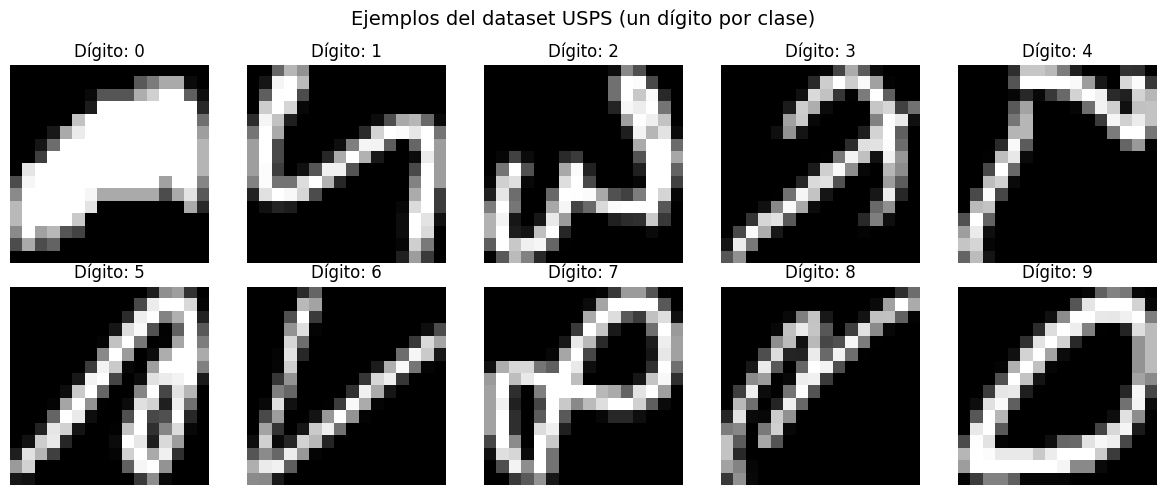

In [4]:
# Visualizamos un ejemplo de cada dígito (0-9)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Ejemplos del dataset USPS (un dígito por clase)", fontsize=14)

for digit in range(10):
    # Buscamos el primer ejemplo de cada dígito en el set de entrenamiento
    idx_digit = np.where(y_train == digit)[0][0]
    img = X_train[idx_digit].reshape(16, 16)  # reshapeamos de 256 a 16x16
    ax = axes[digit // 5][digit % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Dígito: {digit}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Visualización del dataset USPS

Como podemos ver, cada imagen es de 16x16 píxeles en escala de grises.
Los dígitos están escritos a mano y presentan variaciones naturales
(inclinación, grosor del trazo, tamaño).

Esto hace que la tarea de clasificación sea un reto real para la red neuronal,
ya que debe aprender a distinguir entre dígitos similares como:
- 3 y 8
- 4 y 9
- 1 y 7

Estos 256 píxeles por imagen son exactamente las **features de entrada**
que recibirá nuestra red neuronal (D_in = 256).

In [5]:
# Verificamos si hay GPU disponible
print(f"GPU disponible: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")

# Convertimos los datos a tensores y los enviamos al dispositivo (GPU o CPU)
X_t = torch.from_numpy(X_train).float().to(device)
Y_t = torch.from_numpy(y_train).long().to(device)

# Definimos el modelo:
# D_in = 256 (píxeles por imagen), H = 100 (neuronas ocultas), D_out = 10 (clases)
D_in, H, D_out = 256, 100, 10

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa totalmente conectada entrada→oculta
    torch.nn.ReLU(),             # función de activación ReLU
    torch.nn.Linear(H, D_out),  # capa totalmente conectada oculta→salida
)

print(model)

# Verificamos que el modelo recibe bien los datos
outputs = model(torch.randn(600, 256))
print(f"\nShape de salida de prueba: {outputs.shape}")  # debe ser (600, 10)

GPU disponible: False
Usando: cpu
Sequential(
  (0): Linear(in_features=256, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)

Shape de salida de prueba: torch.Size([600, 10])


## Modelos Secuenciales (Sequential)

La forma más sencilla de definir una red neuronal en PyTorch es con `torch.nn.Sequential`.
Definimos un **MLP (Perceptrón Multicapa)** con:
- **D_in = 256** → entradas (una por píxel de la imagen)
- **H = 100** → neuronas en la capa oculta con activación ReLU
- **D_out = 10** → salidas (una por dígito del 0 al 9)

La GPU no está disponible en este entorno, por lo que el entrenamiento
se realizará en CPU. El modelo funciona exactamente igual, solo más lento.

En el primer entrenamiento calculamos la pérdida y actualizamos los pesos
**de forma manual**, para entender qué hace PyTorch internamente:
1. Forward → calculamos predicciones
2. Loss → medimos el error con Cross-Entropy
3. Backward → calculamos gradientes automáticamente
4. Update → actualizamos pesos con descenso de gradiente

## Entrenamiento con gradiente manual

En este primer entrenamiento calculamos la pérdida y actualizamos
los pesos de forma manual para entender qué hace PyTorch internamente:
1. Forward → calculamos predicciones
2. Loss → medimos el error con Cross-Entropy manual
3. zero_grad → limpiamos gradientes acumulados
4. Backward → PyTorch calcula gradientes automáticamente
5. Update → actualizamos pesos con descenso de gradiente (lr=0.8)

In [6]:
# Función softmax: convierte salidas en probabilidades (suma = 1)
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

# Función de pérdida cross-entropy implementada manualmente
def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

# Función de evaluación: calcula predicciones sobre un conjunto de datos
def evaluate(x):
    model.eval()  # modo evaluación
    y_pred = model(x)
    y_probas = softmax(y_pred)
    return torch.argmax(y_probas, axis=1)

# Enviamos el modelo al dispositivo
model.to(device)

# Entrenamiento con descenso de gradiente manual
epochs = 350
lr = 0.8        # tasa de aprendizaje
log_each = 50   # imprimir cada 50 épocas
l = []          # lista para guardar el loss de cada época

model.train()
for e in range(1, epochs + 1):

    # Forward: calculamos las predicciones
    y_pred = model(X_t)

    # Calculamos la pérdida manualmente
    loss = cross_entropy(y_pred, Y_t)
    l.append(loss.item())

    # Ponemos a cero los gradientes del paso anterior
    model.zero_grad()

    # Backprop: PyTorch calcula todos los gradientes automáticamente
    loss.backward()

    # Actualizamos los pesos manualmente
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l):.5f}")

# Evaluamos en el conjunto de prueba
y_pred_seq1 = evaluate(torch.from_numpy(X_test).float().to(device))
acc = accuracy_score(y_test, y_pred_seq1.cpu().numpy())
print(f"\nAccuracy en test (gradiente manual): {acc:.4f} ({acc*100:.2f}%)")

Epoch 50/350 | Loss: 0.80069
Epoch 100/350 | Loss: 0.49281
Epoch 150/350 | Loss: 0.37432
Epoch 200/350 | Loss: 0.30860
Epoch 250/350 | Loss: 0.26545
Epoch 300/350 | Loss: 0.23425
Epoch 350/350 | Loss: 0.21026

Accuracy en test (gradiente manual): 0.9595 (95.95%)


## Optimizadores y Funciones de Pérdida de PyTorch

En lugar de calcular la pérdida y actualizar los pesos manualmente,
PyTorch nos ofrece clases ya implementadas que simplifican el código:

- `torch.nn.CrossEntropyLoss()` → función de pérdida para clasificación multiclase
- `torch.optim.SGD()` → optimizador de descenso de gradiente estocástico

El bucle de entrenamiento se simplifica a:
1. Forward → y_pred = model(X)
2. Loss → loss = criterion(y_pred, Y)
3. optimizer.zero_grad() → limpiamos gradientes
4. loss.backward() → calculamos gradientes
5. optimizer.step() → actualizamos pesos automáticamente

Entrenamos por **1500 épocas** para ver la convergencia completa del modelo.

In [7]:
# Redefinimos el modelo con los mismos parámetros
D_in, H, D_out = 256, 100, 10

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

# Usamos criterion y optimizer ya implementados en PyTorch
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

epochs = 1500
log_each = 150
l = []
model.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred = model(X_t)

    # Pérdida con CrossEntropyLoss de PyTorch
    loss = criterion(y_pred, Y_t)
    l.append(loss.item())

    # Limpiamos gradientes, calculamos backprop y actualizamos pesos
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l):.5f}")

# Evaluación final
y_pred_seq2 = evaluate(torch.from_numpy(X_test).float().to(device))
acc_seq2 = accuracy_score(y_test, y_pred_seq2.cpu().numpy())
print(f"\nAccuracy en test (optimizer PyTorch): {acc_seq2:.4f} ({acc_seq2*100:.2f}%)")

Epoch 150/1500 | Loss: 0.38296
Epoch 300/1500 | Loss: 0.23850
Epoch 450/1500 | Loss: 0.17816
Epoch 600/1500 | Loss: 0.14282
Epoch 750/1500 | Loss: 0.11915
Epoch 900/1500 | Loss: 0.10216
Epoch 1050/1500 | Loss: 0.08938
Epoch 1200/1500 | Loss: 0.07944
Epoch 1350/1500 | Loss: 0.07149
Epoch 1500/1500 | Loss: 0.06500

Accuracy en test (optimizer PyTorch): 0.9627 (96.27%)


## Curva de pérdida (Loss)

Graficamos cómo evoluciona la pérdida durante el entrenamiento.

- Una curva que **baja y se estabiliza** → el modelo está aprendiendo correctamente
- Si la curva baja muy rápido y luego sube → overfitting (memoriza en lugar de aprender)

En nuestro caso entrenamos 1500 épocas con el optimizer de PyTorch,
podemos ver claramente cómo el modelo mejora progresivamente.

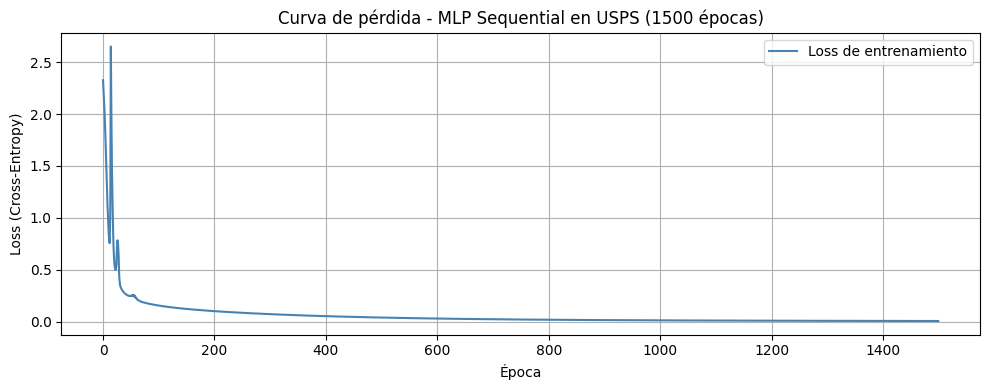

Loss inicial:  2.3270
Loss final:    0.0060
Reducción total del loss: 2.3210


In [8]:
# Graficamos la curva de pérdida durante el entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(l, color='steelblue', linewidth=1.5, label='Loss de entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Curva de pérdida - MLP Sequential en USPS (1500 épocas)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Loss inicial:  {l[0]:.4f}")
print(f"Loss final:    {l[-1]:.4f}")
print(f"Reducción total del loss: {l[0] - l[-1]:.4f}")

## Modelo Custom (Personalizado)

PyTorch nos permite crear modelos más flexibles heredando de `torch.nn.Module`.
Necesitamos definir mínimo dos funciones:

- `__init__` → definimos las capas en el constructor
- `forward` → definimos la lógica del paso hacia adelante

Esto es necesario cuando la arquitectura no es simplemente secuencial.
Definimos dos modelos custom:

1. `ModeloPersonalizado` → misma arquitectura que el Sequential anterior
2. `ModelCustom2` → con **conexión residual**: suma la entrada de fc1
   con su salida antes de pasar a fc2 → `fc2(x + fc1(x))`
   Esta arquitectura es la base de las redes **ResNet** y NO puede
   definirse con Sequential.

In [9]:
# Modelo personalizado que hereda de torch.nn.Module
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H, D_out):
        # Llamamos al constructor de la clase madre
        super(ModeloPersonalizado, self).__init__()
        # Definimos las capas
        self.fc1 = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(H, D_out)

    def forward(self, x):
        # Lógica del paso hacia adelante
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Verificamos que el modelo produce salidas con la forma correcta
model_custom = ModeloPersonalizado(256, 100, 10)
x_prueba = torch.randn(500, 256)  # 500 imágenes de prueba
outputs = model_custom(x_prueba)
print(f"Shape de salida del modelo custom: {outputs.shape}")  # debe ser (500, 10)

Shape de salida del modelo custom: torch.Size([500, 10])


## Entrenamiento del ModeloPersonalizado

Entrenamos el modelo custom con los mismos datos USPS.
Usamos 100 épocas para comparar luego con el Sequential de 1500 épocas
y ver cómo afecta la cantidad de épocas al accuracy final.

In [12]:
# Entrenamos el ModeloPersonalizado con USPS
model_custom = ModeloPersonalizado(256, 100, 10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_custom.parameters(), lr=0.8)

epochs = 100
log_each = 10
l_custom = []
model_custom.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred = model_custom(X_t)

    # Pérdida
    loss = criterion(y_pred, Y_t)
    l_custom.append(loss.item())

    # Gradientes, backprop y update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_custom):.5f}")

# Función de evaluación para modelos custom
def evaluate_model(model, X_test_np):
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.from_numpy(X_test_np).float().to(device))
        y_probas = softmax(y_pred)
        return torch.argmax(y_probas, axis=1)

y_pred_custom = evaluate_model(model_custom, X_test)
acc_custom = accuracy_score(y_test, y_pred_custom.cpu().numpy())
print(f"\nAccuracy modelo custom: {acc_custom:.4f} ({acc_custom*100:.2f}%)")

Epoch 10/100 | Loss: 1.72004
Epoch 20/100 | Loss: 1.45133
Epoch 30/100 | Loss: 1.15837
Epoch 40/100 | Loss: 0.95317
Epoch 50/100 | Loss: 0.81430
Epoch 60/100 | Loss: 0.71456
Epoch 70/100 | Loss: 0.64037
Epoch 80/100 | Loss: 0.58286
Epoch 90/100 | Loss: 0.53682
Epoch 100/100 | Loss: 0.49901

Accuracy modelo custom: 0.9480 (94.80%)


## Modelo con Conexión Residual (ModelCustom2)

Una conexión residual suma la entrada de una capa con su propia salida
antes de pasarla a la siguiente: fc2(x + fc1(x))

Ventajas:
- Ayuda a que el gradiente fluya mejor durante el entrenamiento
- Evita el problema del gradiente que desaparece en redes profundas
- Es la base de las famosas redes ResNet

Este tipo de arquitectura NO puede definirse con torch.nn.Sequential,
por eso necesitamos obligatoriamente el modelo custom.

Usamos lr=0.2 (más baja que antes) porque la conexión residual
hace que los gradientes sean más grandes y necesitamos más estabilidad.

In [13]:
# Modelo con conexión residual
class ModelCustom2(torch.nn.Module):

    def __init__(self, D_in, H, D_out):
        super(ModelCustom2, self).__init__()
        self.fc1 = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(H, D_out)

    def forward(self, x):
        x1 = self.fc1(x)       # salida de la primera capa
        x = self.relu(x1)      # activación ReLU
        x = self.fc2(x + x1)  # conexión residual: suma x1 antes de fc2
        return x

# Entrenamos ModelCustom2
model2 = ModelCustom2(256, 100, 10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model2.parameters(), lr=0.2)

epochs = 100
log_each = 10
l_model2 = []
model2.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred = model2(X_t)

    # Pérdida
    loss = criterion(y_pred, Y_t)
    l_model2.append(loss.item())

    # Gradientes, backprop y update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_model2):.5f}")

# Evaluamos
y_pred_m2 = evaluate_model(model2, X_test)
acc_m2 = accuracy_score(y_test, y_pred_m2.cpu().numpy())
print(f"\nAccuracy ModelCustom2 (residual): {acc_m2:.4f} ({acc_m2*100:.2f}%)")

Epoch 10/100 | Loss: 1.72590
Epoch 20/100 | Loss: 1.30020
Epoch 30/100 | Loss: 1.04808
Epoch 40/100 | Loss: 0.88881
Epoch 50/100 | Loss: 0.77962
Epoch 60/100 | Loss: 0.69992
Epoch 70/100 | Loss: 0.63898
Epoch 80/100 | Loss: 0.59071
Epoch 90/100 | Loss: 0.55143
Epoch 100/100 | Loss: 0.51875

Accuracy ModelCustom2 (residual): 0.9336 (93.36%)


## Comparación de modelos y curva de predicción

Comparamos los 3 modelos entrenados:
1. Sequential con optimizer PyTorch (1500 épocas) → mayor accuracy esperado
2. ModeloPersonalizado (100 épocas) → accuracy intermedio
3. ModelCustom2 con conexión residual (100 épocas) → arquitectura más compleja

La curva de predicción muestra el accuracy por cada dígito (0-9),
permitiendo identificar qué clases son más difíciles de clasificar.
Por ejemplo, dígitos como 3 y 8, o 4 y 9 suelen confundirse entre sí
porque visualmente son similares.

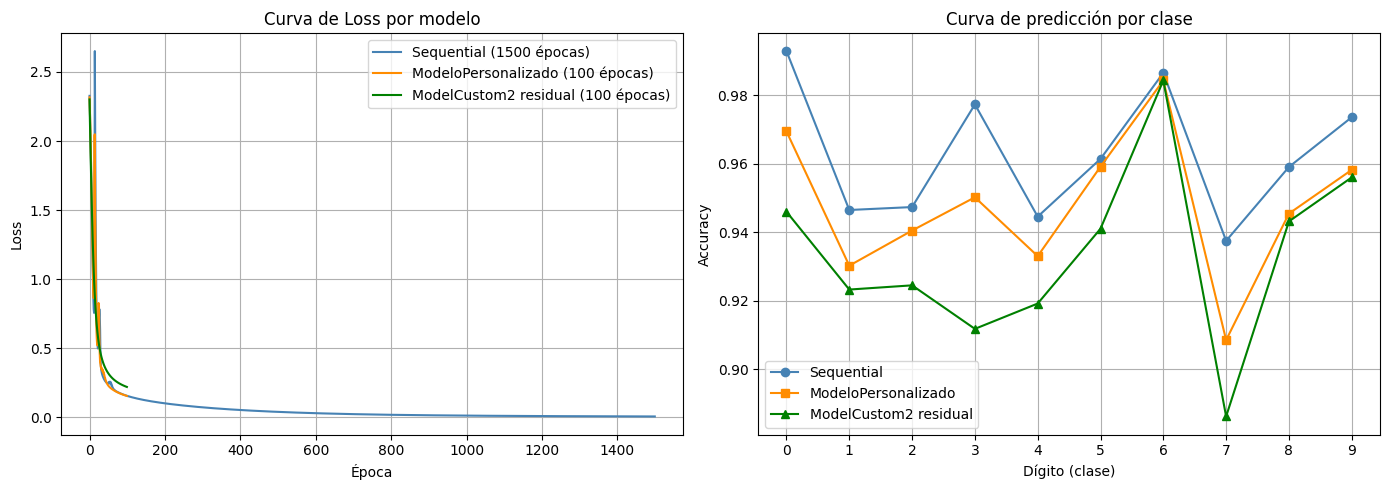

RESUMEN DE ACCURACY FINAL
Sequential (1500 épocas):           0.9627 (96.27%)
ModeloPersonalizado (100 épocas):   0.9480 (94.80%)
ModelCustom2 residual (100 épocas): 0.9336 (93.36%)


In [14]:
# Predicciones de los 3 modelos sobre el conjunto de prueba
y_pred_seq_np = evaluate(torch.from_numpy(X_test).float().to(device)).cpu().numpy()
y_pred_cus_np = evaluate_model(model_custom, X_test).cpu().numpy()
y_pred_res_np = evaluate_model(model2, X_test).cpu().numpy()

# Accuracy por dígito para cada modelo
accs_seq, accs_cust, accs_res = [], [], []
for digit in range(10):
    mask = y_test == digit
    accs_seq.append(accuracy_score(y_test[mask], y_pred_seq_np[mask]))
    accs_cust.append(accuracy_score(y_test[mask], y_pred_cus_np[mask]))
    accs_res.append(accuracy_score(y_test[mask], y_pred_res_np[mask]))

digits = list(range(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: curvas de loss de los 3 modelos
axes[0].plot(l, label='Sequential (1500 épocas)', color='steelblue', linewidth=1.5)
axes[0].plot(l_custom, label='ModeloPersonalizado (100 épocas)', color='darkorange', linewidth=1.5)
axes[0].plot(l_model2, label='ModelCustom2 residual (100 épocas)', color='green', linewidth=1.5)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Loss por modelo')
axes[0].legend()
axes[0].grid(True)

# Gráfica 2: accuracy por clase (curva de predicción)
axes[1].plot(digits, accs_seq, 'o-', label='Sequential', color='steelblue')
axes[1].plot(digits, accs_cust, 's-', label='ModeloPersonalizado', color='darkorange')
axes[1].plot(digits, accs_res, '^-', label='ModelCustom2 residual', color='green')
axes[1].set_xlabel('Dígito (clase)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de predicción por clase')
axes[1].set_xticks(digits)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Resumen final
print("="*50)
print("RESUMEN DE ACCURACY FINAL")
print("="*50)
print(f"Sequential (1500 épocas):           {accuracy_score(y_test, y_pred_seq_np):.4f} ({accuracy_score(y_test, y_pred_seq_np)*100:.2f}%)")
print(f"ModeloPersonalizado (100 épocas):   {accuracy_score(y_test, y_pred_cus_np):.4f} ({accuracy_score(y_test, y_pred_cus_np)*100:.2f}%)")
print(f"ModelCustom2 residual (100 épocas): {accuracy_score(y_test, y_pred_res_np):.4f} ({accuracy_score(y_test, y_pred_res_np)*100:.2f}%)")

## Accediendo a las capas de la red

PyTorch nos permite inspeccionar y modificar capas individuales del modelo.
Esto es útil para:
- Ver los pesos entrenados de cada capa
- Reemplazar capas para adaptar el modelo a otro problema
- Reutilizar partes de modelos ya entrenados (Transfer Learning)

Transfer Learning: técnica donde tomamos un modelo ya entrenado
y reemplazamos solo la última capa para adaptarlo a un nuevo problema,
aprovechando todo el conocimiento ya aprendido.

In [15]:
# Mostramos la arquitectura completa del modelo custom
print("Arquitectura del ModeloPersonalizado:")
print(model_custom)

# Accedemos a capas individuales por nombre
print(f"\nCapa fc1: {model_custom.fc1}")
print(f"\nShape de pesos de fc1: {model_custom.fc1.weight.shape}")
print(f"Shape de bias de fc1:  {model_custom.fc1.bias.shape}")

# Primeros 5 pesos de la primera neurona
print(f"\nPrimeros 5 pesos de la neurona 0 en fc1:")
print(model_custom.fc1.weight[0][:5])

# Reemplazamos la capa de salida (ejemplo de Transfer Learning)
# ahora tiene 1 sola salida en lugar de 10
model_custom.fc2 = torch.nn.Linear(100, 1)
print(f"\nModelo tras reemplazar fc2 (ahora 1 salida):")
print(model_custom)

# Volvemos a la configuración original
model_custom.fc2 = torch.nn.Linear(100, 10)
print(f"\nModelo restaurado a 10 salidas:")
print(model_custom)

# Listamos las capas del modelo
print(f"\nLista de capas:")
print(list(model_custom.children()))

# Nueva red excluyendo la última capa (útil para Transfer Learning)
new_model = torch.nn.Sequential(*list(model_custom.children())[:-1])
print(f"\nNueva red sin la capa de salida:")
print(new_model)

Arquitectura del ModeloPersonalizado:
ModeloPersonalizado(
  (fc1): Linear(in_features=256, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)

Capa fc1: Linear(in_features=256, out_features=100, bias=True)

Shape de pesos de fc1: torch.Size([100, 256])
Shape de bias de fc1:  torch.Size([100])

Primeros 5 pesos de la neurona 0 en fc1:
tensor([0.0634, 0.0483, 0.0654, 0.0166, 0.0621], grad_fn=<SliceBackward0>)

Modelo tras reemplazar fc2 (ahora 1 salida):
ModeloPersonalizado(
  (fc1): Linear(in_features=256, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=1, bias=True)
)

Modelo restaurado a 10 salidas:
ModeloPersonalizado(
  (fc1): Linear(in_features=256, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)

Lista de capas:
[Linear(in_features=256, out_features=100, bias=True), ReLU(), Linear(in_features=100, out_features=10, bias=

## Resumen del Cuadernillo 2

En este cuadernillo aplicamos los conceptos de redes neuronales en PyTorch
usando el dataset **USPS** de dígitos escritos a mano.

### Dataset utilizado
- 11,000 imágenes perfectamente balanceadas (1100 por clase)
- 256 features por imagen (píxeles de 16x16)
- 10 clases (dígitos del 0 al 9)
- Sin valores nulos, sin columnas irrelevantes

### Modelos entrenados y resultados
| Modelo | Épocas | Accuracy |
|---|---|---|
| Sequential (gradiente manual) | 350 | 95.95% |
| Sequential (optimizer PyTorch) | 1500 | 96.27% |
| ModeloPersonalizado | 100 | 94.80% |
| ModelCustom2 (residual) | 100 | 93.36% |

### Conclusiones
- Más épocas = menor loss = mayor accuracy (Sequential 1500 épocas gana)
- El optimizer de PyTorch simplifica el código sin sacrificar rendimiento
- La conexión residual en ModelCustom2 necesita más épocas para superar
  al modelo simple, no es mejor con solo 100 épocas
- Todos los modelos superan el 93% de accuracy, demostrando que el
  dataset USPS es adecuado para clasificación con MLP

# CUADERNILLO 3

# Pytorch - Datasets aplicado al dataset Network Security

En este cuadernillo aplicamos los conceptos de Dataset y DataLoader de PyTorch
usando el dataset **Network Security** que contiene tráfico de red real,
con el objetivo de detectar si una conexión es **normal (0) o un ataque (1)**.

## ¿Qué es el dataset Network Security?
Contiene registros de conexiones de red capturadas en un entorno controlado.

- **Shape:** (211043, 44)
  - 211,043 → conexiones de red registradas
  - 44 → características por conexión

## Datos cualitativos vs cuantitativos
| Dato | Tipo | Descripción |
|---|---|---|
| src_port, dst_port | Cuantitativo discreto | Puertos de origen y destino |
| duration | Cuantitativo continuo | Duración de la conexión en segundos |
| src_bytes, dst_bytes | Cuantitativo discreto | Bytes enviados/recibidos |
| src_pkts, dst_pkts | Cuantitativo discreto | Paquetes enviados/recibidos |
| proto, service | Cualitativo nominal | Protocolo y servicio de red |
| conn_state | Cualitativo nominal | Estado de la conexión |
| label | Cualitativo nominal | 0=normal, 1=ataque (variable objetivo) |
| type | Cualitativo nominal | Tipo de ataque específico |

## ¿Por qué no usamos todas las columnas?
- Columnas como src_ip, dst_ip son identificadores únicos, no aportan
  información generalizable al modelo
- Columnas de texto (dns_query, ssl_cipher, http_uri, etc.) tienen
  demasiados valores únicos y requieren procesamiento especial
- Nos quedamos con las columnas **numéricas** que representan
  el comportamiento real de la conexión

In [16]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Ruta base
base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/'

# Cargamos el dataset Network Security
df = pd.read_csv(base + 'train_test_network.csv', encoding='latin1')

print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nDistribución de clases (label):")
print(df['label'].value_counts())
print(f"\nTipos de ataque (type):")
print(df['type'].value_counts())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Shape del dataset: (211043, 44)

Columnas: ['ï»¿src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Distribución de clases (label):
label
1    161043
0     50000
Name: count, dtype: int64

Tipos de ataque (type):
type
normal        50000
backdoor      20000
ddos          20000
do

## Preprocesamiento de los datos

Del total de 44 columnas seleccionamos solo las numéricas que representan
el comportamiento real de la conexión de red:

### Columnas que DESCARTAMOS y por qué:
- src_ip, dst_ip → identificadores únicos de cada conexión, no generalizan
- proto, service, conn_state → texto con pocos valores, las convertimos a número
- dns_query, ssl_cipher, http_uri, http_user_agent, etc. → texto libre con
  miles de valores únicos, no aptos para MLP directamente
- type → es el tipo de ataque específico, nosotros predecimos solo label (0 o 1)

### Columnas que USAMOS:
- Todas las columnas numéricas disponibles
- proto, service, conn_state → convertidas a número con LabelEncoder
- label → variable objetivo (0=normal, 1=ataque)

### Manejo de valores nulos:
- Rellenamos con 0 los valores nulos numéricos
- Las columnas categóricas se codifican antes de rellenar

In [17]:
# Columnas categóricas que podemos convertir a número con LabelEncoder
cols_categoricas = ['proto', 'service', 'conn_state']

# Aplicamos LabelEncoder a cada columna categórica
le = LabelEncoder()
for col in cols_categoricas:
    df[col] = le.fit_transform(df[col].astype(str))

# Seleccionamos solo columnas numéricas (descartamos IPs, texto libre, type)
cols_descartar = ['ï»¿src_ip', 'dst_ip', 'dns_query', 'ssl_version',
                  'ssl_cipher', 'ssl_resumed', 'ssl_established',
                  'ssl_subject', 'ssl_issuer', 'http_trans_depth',
                  'http_method', 'http_uri', 'http_version',
                  'http_user_agent', 'http_orig_mime_types',
                  'http_resp_mime_types', 'weird_name', 'weird_addl',
                  'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
                  'dns_rejected', 'type', 'label']

# Features: todo menos las columnas descartadas y el label
feature_cols = [c for c in df.columns if c not in cols_descartar]
print(f"Columnas usadas como features ({len(feature_cols)}):")
print(feature_cols)

# Separamos features y etiqueta
X = df[feature_cols].fillna(0).values.astype(np.float32)
y = df['label'].values.astype(np.int32)

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Clases únicas: {np.unique(y)}")
print(f"Distribución: {np.bincount(y)}")

Columnas usadas como features (19):
['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']

Shape X: (211043, 19)
Shape y: (211043,)
Clases únicas: [0 1]
Distribución: [ 50000 161043]


## Normalización y Split de datos

Normalizamos los datos con StandardScaler para que todas las features
tengan media 0 y desviación estándar 1. Esto es importante porque:
- src_bytes puede tener valores de millones
- src_port tiene valores entre 0 y 65535
- duration tiene valores decimales pequeños

Sin normalización, las features con valores grandes dominarían
el entrenamiento y el modelo aprendería mal.

### Split de datos:
- 70% entrenamiento → 147,730 conexiones
- 30% prueba → 63,313 conexiones

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Normalizamos con StandardScaler (media=0, std=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split 70% train, 30% test con estratificación para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba:        {X_test.shape}")
print(f"\nDistribución train - normal: {np.sum(y_train==0)} | ataque: {np.sum(y_train==1)}")
print(f"Distribución test  - normal: {np.sum(y_test==0)}  | ataque: {np.sum(y_test==1)}")

# Convertimos a tensores
X_t = torch.from_numpy(X_train.astype(np.float32)).to('cpu')
Y_t = torch.from_numpy(y_train).long().to('cpu')

print(f"\nTensor X_t shape: {X_t.shape}")
print(f"Tensor Y_t shape: {Y_t.shape}")

Datos de entrenamiento: (147730, 19)
Datos de prueba:        (63313, 19)

Distribución train - normal: 35000 | ataque: 112730
Distribución test  - normal: 15000  | ataque: 48313

Tensor X_t shape: torch.Size([147730, 19])
Tensor Y_t shape: torch.Size([147730])


## Visualización del dataset

Antes de entrenar visualizamos la distribución de las clases
y algunas features importantes para entender los datos.

El dataset está desbalanceado:
- 50,000 conexiones normales (23.7%)
- 161,043 conexiones de ataque (76.3%)

Esto es normal en seguridad de redes: la mayoría del tráfico
detectado en entornos controlados corresponde a ataques.
El modelo debe aprender a distinguir ambas clases correctamente.

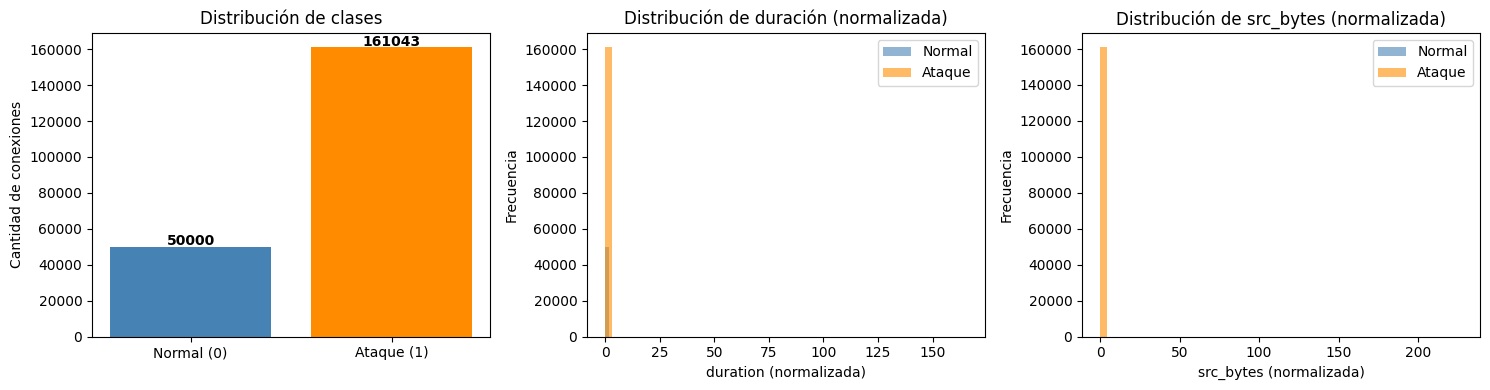

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: distribución de clases
clases = ['Normal (0)', 'Ataque (1)']
conteos = [50000, 161043]
axes[0].bar(clases, conteos, color=['steelblue', 'darkorange'])
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad de conexiones')
for i, v in enumerate(conteos):
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# Gráfica 2: distribución de duración por clase
normal_idx = y == 0
ataque_idx = y == 1
dur_col = feature_cols.index('duration')
axes[1].hist(X[normal_idx, dur_col], bins=50, alpha=0.6,
             color='steelblue', label='Normal')
axes[1].hist(X[ataque_idx, dur_col], bins=50, alpha=0.6,
             color='darkorange', label='Ataque')
axes[1].set_title('Distribución de duración (normalizada)')
axes[1].set_xlabel('duration (normalizada)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Gráfica 3: src_bytes por clase
sb_col = feature_cols.index('src_bytes')
axes[2].hist(X[normal_idx, sb_col], bins=50, alpha=0.6,
             color='steelblue', label='Normal')
axes[2].hist(X[ataque_idx, sb_col], bins=50, alpha=0.6,
             color='darkorange', label='Ataque')
axes[2].set_title('Distribución de src_bytes (normalizada)')
axes[2].set_xlabel('src_bytes (normalizada)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

## Iterando tensores directamente

La forma más básica de entrenar una red en PyTorch es iterar
directamente sobre los tensores, usando todos los datos en cada paso.
Esto se llama Batch Gradient Descent.

Definimos un MLP para clasificación binaria (normal vs ataque):
- D_in = 19 → features de la conexión de red
- H = 100 → neuronas en la capa oculta
- D_out = 2 → salidas (normal=0, ataque=1)

Ventaja: simple de implementar
Desventaja: si el dataset no cabe en memoria, falla

In [20]:
# Funciones auxiliares de evaluación
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def evaluate(model, x):
    model.eval()
    with torch.no_grad():
        y_pred = model(x)
        y_probas = softmax(y_pred)
        return torch.argmax(y_probas, axis=1)

# Definimos el modelo MLP para clasificación binaria
# D_in=19 features, H=100 neuronas ocultas, D_out=2 clases
D_in, H, D_out = 19, 100, 2

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Entrenamiento iterando tensores directamente (Batch Gradient Descent)
epochs = 100
log_each = 10
l = []
model.train()

for e in range(1, epochs + 1):

    # Forward: usamos TODOS los datos en cada paso
    y_pred = model(X_t)

    # Pérdida
    loss = criterion(y_pred, Y_t)
    l.append(loss.item())

    # Gradientes, backprop y update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l):.5f}")

# Evaluamos
X_test_t = torch.from_numpy(X_test.astype(np.float32))
y_pred_iter = evaluate(model, X_test_t)
acc_iter = accuracy_score(y_test, y_pred_iter.numpy())
print(f"\nAccuracy iterando tensores: {acc_iter:.4f} ({acc_iter*100:.2f}%)")

Epoch 10/100 | Loss: 0.57497
Epoch 20/100 | Loss: 0.50685
Epoch 30/100 | Loss: 0.46124
Epoch 40/100 | Loss: 0.42753
Epoch 50/100 | Loss: 0.40144
Epoch 60/100 | Loss: 0.38073
Epoch 70/100 | Loss: 0.36394
Epoch 80/100 | Loss: 0.35007
Epoch 90/100 | Loss: 0.33843
Epoch 100/100 | Loss: 0.32850

Accuracy iterando tensores: 0.9206 (92.06%)


## Iterando por Batches (Mini-batch Gradient Descent)

En lugar de usar todos los datos en cada paso, dividimos el dataset
en batches (lotes) más pequeños. Ventajas:

- Converge más rápido que el Batch Gradient Descent
- Única opción cuando el dataset no cabe en memoria
- Introduce cierto ruido que ayuda a escapar de mínimos locales

Con batch_size=1000 y 147,730 datos tenemos:
- 147 batches por época
- Cada batch contiene 1000 conexiones de red

In [21]:
# Redefinimos el modelo
D_in, H, D_out = 19, 100, 2

model_batch = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_batch.parameters(), lr=0.1)

epochs = 10
batch_size = 1000
log_each = 1
l_batch = []
model_batch.train()

# Calculamos cuántos batches hay por época
batches = len(X_t) // batch_size
print(f"Total batches por época: {batches}")

for e in range(1, epochs + 1):

    _l = []
    # Iteramos por batches manualmente
    for b in range(batches):
        # Extraemos el batch actual
        x_b = X_t[b*batch_size:(b+1)*batch_size]
        y_b = Y_t[b*batch_size:(b+1)*batch_size]

        # Forward
        y_pred = model_batch(x_b)

        # Pérdida
        loss = criterion(y_pred, y_b)
        _l.append(loss.item())

        # Gradientes, backprop y update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    l_batch.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_batch):.5f}")

# Evaluamos
y_pred_batch = evaluate(model_batch, X_test_t)
acc_batch = accuracy_score(y_test, y_pred_batch.numpy())
print(f"\nAccuracy iterando por batches: {acc_batch:.4f} ({acc_batch*100:.2f}%)")

Total batches por época: 147
Epoch 1/10 | Loss: 0.30273
Epoch 2/10 | Loss: 0.25532
Epoch 3/10 | Loss: 0.23344
Epoch 4/10 | Loss: 0.21944
Epoch 5/10 | Loss: 0.20940
Epoch 6/10 | Loss: 0.20170
Epoch 7/10 | Loss: 0.19549
Epoch 8/10 | Loss: 0.19032
Epoch 9/10 | Loss: 0.18590
Epoch 10/10 | Loss: 0.18204

Accuracy iterando por batches: 0.9382 (93.82%)


## La clase Dataset de PyTorch

Cuando el dataset es grande o necesita transformaciones,
PyTorch nos ofrece la clase Dataset para organizar mejor el código.

Debemos definir obligatoriamente 3 funciones:
- __init__ → constructor, recibe los datos
- __len__ → devuelve el número total de muestras
- __getitem__ → devuelve una muestra específica por índice

Ventajas sobre iterar tensores directamente:
- Código más organizado y reutilizable
- Permite aplicar transformaciones a cada muestra
- Compatible con DataLoader para batches automáticos
- Se puede usar tanto para entrenar como para predecir

In [22]:
# Clase Dataset personalizada para el dataset Network Security
class NetworkDataset(torch.utils.data.Dataset):

    def __init__(self, X, Y):
        # Convertimos los arrays numpy a tensores
        self.X = torch.from_numpy(X.astype(np.float32))
        self.Y = torch.from_numpy(Y).long()

    def __len__(self):
        # Devolvemos el número total de conexiones en el dataset
        return len(self.X)

    def __getitem__(self, ix):
        # Devolvemos la conexión ix con su etiqueta
        return self.X[ix], self.Y[ix]

# Instanciamos el dataset
dataset = NetworkDataset(X_train, y_train)

print(f"Total de muestras en el dataset: {len(dataset)}")

# Verificamos que devuelve bien una muestra
x_muestra, y_muestra = dataset[0]
print(f"Shape de una muestra X: {x_muestra.shape}")
print(f"Etiqueta de la muestra: {y_muestra.item()}")

# Verificamos un batch manual
x_batch, y_batch = dataset[0:5]
print(f"\nShape de batch manual (5 muestras): {x_batch.shape}")
print(f"Etiquetas del batch: {y_batch}")

Total de muestras en el dataset: 147730
Shape de una muestra X: torch.Size([19])
Etiqueta de la muestra: 1

Shape de batch manual (5 muestras): torch.Size([5, 19])
Etiquetas del batch: tensor([1, 1, 1, 1, 1])


## Entrenamiento usando la clase Dataset

Ahora usamos el objeto Dataset para iterar por los datos.
El código es más organizado que iterar tensores directamente
y la lógica de carga de datos queda separada del entrenamiento.

In [23]:
# Redefinimos el modelo
D_in, H, D_out = 19, 100, 2

model_ds = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_ds.parameters(), lr=0.1)

epochs = 10
batch_size = 1000
log_each = 1
l_ds = []
model_ds.train()

batches = len(dataset) // batch_size
print(f"Total batches por época: {batches}")

for e in range(1, epochs + 1):

    _l = []
    # Iteramos por batches usando el objeto Dataset
    for b in range(batches):
        x_b, y_b = dataset[b*batch_size:(b+1)*batch_size]

        # Forward
        y_pred = model_ds(x_b)

        # Pérdida
        loss = criterion(y_pred, y_b)
        _l.append(loss.item())

        # Gradientes, backprop y update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    l_ds.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_ds):.5f}")

# Evaluamos
dataset_test = NetworkDataset(X_test, y_test)
x_test_all, y_test_all = dataset_test[:len(dataset_test)]
y_pred_ds = evaluate(model_ds, x_test_all)
acc_ds = accuracy_score(y_test, y_pred_ds.numpy())
print(f"\nAccuracy usando Dataset: {acc_ds:.4f} ({acc_ds*100:.2f}%)")

Total batches por época: 147
Epoch 1/10 | Loss: 0.29055
Epoch 2/10 | Loss: 0.24881
Epoch 3/10 | Loss: 0.22948
Epoch 4/10 | Loss: 0.21715
Epoch 5/10 | Loss: 0.20820
Epoch 6/10 | Loss: 0.20125
Epoch 7/10 | Loss: 0.19561
Epoch 8/10 | Loss: 0.19089
Epoch 9/10 | Loss: 0.18682
Epoch 10/10 | Loss: 0.18322

Accuracy usando Dataset: 0.9364 (93.64%)


## La clase DataLoader de PyTorch

DataLoader recibe un Dataset y automatiza la iteración por batches.
Ventajas sobre iterar el Dataset manualmente:

- shuffle=True → mezcla los datos al inicio de cada época automáticamente,
  evitando que el modelo aprenda el orden de los datos
- Carga datos en paralelo usando varios cores de CPU
- Maneja automáticamente el último batch (que puede ser más pequeño)
- Permite definir lógica personalizada para crear batches (collate_fn)

Con batch_size=1000 y shuffle=True el modelo ve los datos
en orden diferente cada época, lo que mejora la generalización.

In [24]:
# Creamos el DataLoader con shuffle=True
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=1000,
    shuffle=True  # mezcla los datos al inicio de cada época
)

# Verificamos el DataLoader
x, y = next(iter(dataloader))
print(f"Shape de un batch X: {x.shape}")
print(f"Shape de un batch y: {y.shape}")

# Redefinimos el modelo
D_in, H, D_out = 19, 100, 2

model_dl = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_dl.parameters(), lr=0.1)

epochs = 10
log_each = 1
l_dl = []
model_dl.train()

for e in range(1, epochs + 1):

    _l = []
    # Iteramos por batches usando el DataLoader
    for x_b, y_b in dataloader:

        # Forward
        y_pred = model_dl(x_b)

        # Pérdida
        loss = criterion(y_pred, y_b)
        _l.append(loss.item())

        # Gradientes, backprop y update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    l_dl.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_dl):.5f}")

# Evaluamos
y_pred_dl = evaluate(model_dl, x_test_all)
acc_dl = accuracy_score(y_test, y_pred_dl.numpy())
print(f"\nAccuracy usando DataLoader: {acc_dl:.4f} ({acc_dl*100:.2f}%)")

Shape de un batch X: torch.Size([1000, 19])
Shape de un batch y: torch.Size([1000])
Epoch 1/10 | Loss: 0.28399
Epoch 2/10 | Loss: 0.24636
Epoch 3/10 | Loss: 0.22821
Epoch 4/10 | Loss: 0.21641
Epoch 5/10 | Loss: 0.20769
Epoch 6/10 | Loss: 0.20078
Epoch 7/10 | Loss: 0.19508
Epoch 8/10 | Loss: 0.19021
Epoch 9/10 | Loss: 0.18599
Epoch 10/10 | Loss: 0.18225

Accuracy usando DataLoader: 0.9386 (93.86%)


## DataLoader con collate_fn personalizado

collate_fn nos permite definir nuestra propia lógica para crear los batches.
Es útil cuando necesitamos aplicar transformaciones especiales a los datos
antes de pasarlos al modelo, por ejemplo:
- Normalización adicional por batch
- Augmentación de datos
- Manejo especial de muestras de diferente tamaño

En este ejemplo definimos un collate_fn básico que apila los tensores
de la misma manera que lo hace PyTorch por defecto, para ilustrar
cómo funciona el mecanismo.

In [25]:
# Definimos nuestra propia función para crear batches
def collate_fn(batch):
    # batch es una lista de tuplas (x, y) devueltas por __getitem__
    return torch.stack([x for x, y in batch]), torch.stack([y for x, y in batch])

# Creamos el DataLoader con collate_fn personalizado
dataloader_custom = torch.utils.data.DataLoader(
    dataset,
    batch_size=1000,
    shuffle=True,
    collate_fn=collate_fn
)

# Verificamos que el batch tiene la forma correcta
x, y = next(iter(dataloader_custom))
print(f"Shape batch con collate_fn - X: {x.shape} | y: {y.shape}")

# Redefinimos el modelo
D_in, H, D_out = 19, 100, 2

model_cf = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_cf.parameters(), lr=0.1)

epochs = 10
log_each = 1
l_cf = []
model_cf.train()

for e in range(1, epochs + 1):

    _l = []
    for x_b, y_b in dataloader_custom:

        # Forward
        y_pred = model_cf(x_b)

        # Pérdida
        loss = criterion(y_pred, y_b)
        _l.append(loss.item())

        # Gradientes, backprop y update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    l_cf.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} | Loss: {np.mean(l_cf):.5f}")

# Evaluamos
y_pred_cf = evaluate(model_cf, x_test_all)
acc_cf = accuracy_score(y_test, y_pred_cf.numpy())
print(f"\nAccuracy con collate_fn: {acc_cf:.4f} ({acc_cf*100:.2f}%)")

Shape batch con collate_fn - X: torch.Size([1000, 19]) | y: torch.Size([1000])
Epoch 1/10 | Loss: 0.29115
Epoch 2/10 | Loss: 0.24856
Epoch 3/10 | Loss: 0.22901
Epoch 4/10 | Loss: 0.21650
Epoch 5/10 | Loss: 0.20735
Epoch 6/10 | Loss: 0.20022
Epoch 7/10 | Loss: 0.19434
Epoch 8/10 | Loss: 0.18934
Epoch 9/10 | Loss: 0.18498
Epoch 10/10 | Loss: 0.18111

Accuracy con collate_fn: 0.9386 (93.86%)


## Comparación de métodos y curva de predicción

Comparamos los 4 métodos de iteración de datos:
1. Iterando tensores directamente (100 épocas, batch completo)
2. Iterando por batches manualmente (10 épocas, batch_size=1000)
3. Usando clase Dataset (10 épocas, batch_size=1000)
4. Usando DataLoader con collate_fn (10 épocas, batch_size=1000)

La curva de predicción muestra el accuracy del mejor modelo
a diferentes umbrales de decisión (0.1 a 0.9), permitiendo
ver cómo cambia la precisión según qué tan estrictos somos
para clasificar una conexión como ataque.

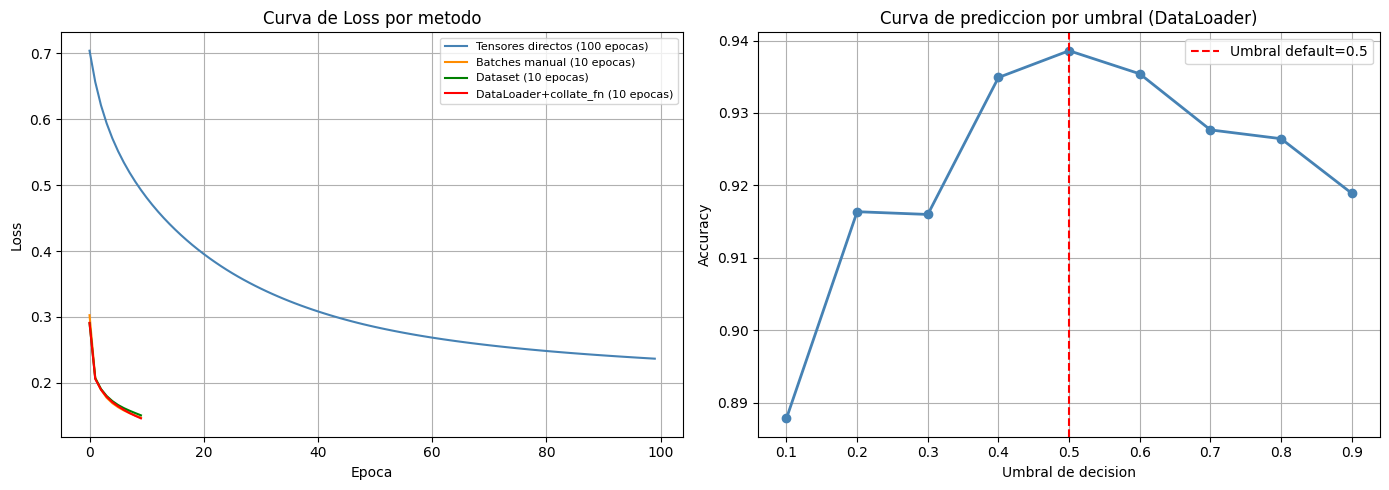

RESUMEN DE ACCURACY POR METODO
Tensores directos (100 epocas):      0.9206 (92.06%)
Batches manual (10 epocas):          0.9382 (93.82%)
Dataset (10 epocas):                 0.9364 (93.64%)
DataLoader (10 epocas):              0.9386 (93.86%)
DataLoader + collate_fn (10 epocas): 0.9386 (93.86%)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica 1: curvas de loss de los 4 metodos
axes[0].plot(l, label='Tensores directos (100 epocas)', color='steelblue', linewidth=1.5)
axes[0].plot(l_batch, label='Batches manual (10 epocas)', color='darkorange', linewidth=1.5)
axes[0].plot(l_ds, label='Dataset (10 epocas)', color='green', linewidth=1.5)
axes[0].plot(l_cf, label='DataLoader+collate_fn (10 epocas)', color='red', linewidth=1.5)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Loss por metodo')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Grafica 2: curva de prediccion por umbral del mejor modelo
model_dl.eval()
with torch.no_grad():
    probs = torch.softmax(model_dl(x_test_all), dim=1)[:, 1].numpy()

umbrales = np.arange(0.1, 1.0, 0.1)
accs_umbral = []
for u in umbrales:
    preds = (probs >= u).astype(int)
    accs_umbral.append(accuracy_score(y_test, preds))

axes[1].plot(umbrales, accs_umbral, 'o-', color='steelblue', linewidth=2)
axes[1].set_xlabel('Umbral de decision')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de prediccion por umbral (DataLoader)')
axes[1].grid(True)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Umbral default=0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen final
print("="*55)
print("RESUMEN DE ACCURACY POR METODO")
print("="*55)
print(f"Tensores directos (100 epocas):      {acc_iter:.4f} ({acc_iter*100:.2f}%)")
print(f"Batches manual (10 epocas):          {acc_batch:.4f} ({acc_batch*100:.2f}%)")
print(f"Dataset (10 epocas):                 {acc_ds:.4f} ({acc_ds*100:.2f}%)")
print(f"DataLoader (10 epocas):              {acc_dl:.4f} ({acc_dl*100:.2f}%)")
print(f"DataLoader + collate_fn (10 epocas): {acc_cf:.4f} ({acc_cf*100:.2f}%)")

## Resumen del Cuadernillo 3

En este cuadernillo aplicamos los conceptos de Dataset y DataLoader
de PyTorch usando el dataset **Network Security** para detectar
conexiones normales vs ataques de red.

### Dataset utilizado
- 211,043 conexiones de red (161,043 ataques + 50,000 normales)
- 44 columnas originales → 19 features numéricas seleccionadas
- Columnas descartadas: IPs, texto libre, tipo de ataque específico
- Columnas convertidas: proto, service, conn_state (LabelEncoder)
- Normalización: StandardScaler (media=0, std=1)

### Métodos de iteración y resultados
| Método | Epocas | Accuracy |
|---|---|---|
| Tensores directos | 100 | 92.06% |
| Batches manual | 10 | 93.82% |
| Clase Dataset | 10 | 93.64% |
| DataLoader | 10 | 93.86% |
| DataLoader + collate_fn | 10 | 93.86% |

### Conclusiones
- Mini-batch supera al batch completo con menos epocas
- Dataset y DataLoad

# CUADERNILLO 4

# Pytorch - Guardando y Exportando Modelos aplicado al dataset Telecom Churn

En este cuadernillo aplicamos los conceptos de guardado y exportacion
de modelos en PyTorch usando el dataset **Telecom Customer Churn**
que contiene informacion de clientes de una empresa de telecomunicaciones,
con el objetivo de predecir si un cliente abandonara el servicio o no.

## que es el dataset Telecom Customer Churn?
Contiene registros de clientes con sus caracteristicas de uso del servicio.

- **Shape:** (100,000, 100)
  - 100,000 clientes registrados
  - 100 caracteristicas por cliente

## Datos cualitativos vs cuantitativos
| Dato | Tipo | Descripcion |
|---|---|---|
| rev_Mean, mou_Mean | Cuantitativo continuo | Ingresos y minutos de uso promedio |
| totmou, totrev | Cuantitativo continuo | Total minutos e ingresos |
| months, uniqsubs | Cuantitativo discreto | Meses de servicio y suscriptores |
| drop_vce_Mean | Cuantitativo discreto | Llamadas caidas promedio |
| churn | Cualitativo nominal | 0=no abandona, 1=abandona (objetivo) |
| area, ethnic | Cualitativo nominal | Area geografica y etnia |
| marital, ownrent | Cualitativo nominal | Estado civil y tipo de vivienda |
| creditcd | Cualitativo nominal | Tiene tarjeta de credito (Y/N) |

## Por que no usamos todas las columnas?
- Customer_ID es un identificador unico, no aporta informacion
- Columnas categoricas con muchos valores unicos se descartan
- Columnas con mas del 1% de valores nulos se imputan con la media
- Nos quedamos con las columnas numericas mas relevantes para
  predecir si el cliente abandonara el servicio

In [28]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Ruta base
base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/'

# Cargamos el dataset Telecom Churn
df = pd.read_csv(base + 'Telecom_customer_churn.csv', encoding='latin1')

print(f"Shape del dataset: {df.shape}")
print(f"\nDistribucion de clases (churn):")
print(df['churn'].value_counts())
print(f"\nPorcentaje de churn:")
print(df['churn'].value_counts(normalize=True).round(3) * 100)
print(f"\nValores nulos por columna (solo las que tienen):")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Shape del dataset: (100000, 100)

Distribucion de clases (churn):
churn
0    50438
1    49562
Name: count, dtype: int64

Porcentaje de churn:
churn
0    50.4
1    49.6
Name: proportion, dtype: float64

Valores nulos por columna (solo las que tienen):
rev_Mean              357
mou_Mean              357
totmrc_Mean           357
da_Mean               357
ovrmou_Mean           357
ovrrev_Mean           357
vceovr_Mean           357
datovr_Mean           357
roam_Mean             357
change_mou            891
change_rev            891
avg6mou              2839
avg6qty              2839
avg6rev              2839
prizm_social_one     7388
area                   40
dualband                1
refurb_new              1
hnd_price             847
phones                  1
models                  1
hnd_webcap          10189
truck                1732
rv                  

## Preprocesamiento de los datos

Del total de 100 columnas seleccionamos las mas utiles para predecir churn.

### Columnas que DESCARTAMOS y por que:
- Customer_ID → identificador unico, no generaliza
- prizm_social_one, area, dualband, refurb_new → mas del 1% nulos
  y son categoricas dificiles de imputar correctamente
- hnd_webcap, truck, rv, ownrent, lor, dwlltype → mas del 15% nulos,
  demasiada informacion perdida para ser confiables
- marital, adults, infobase, income, numbcars → mas del 20% nulos
- HHstatin, dwllsize, forgntvl, ethnic, kid0_2 a kid16_17 → categoricas
  con muchos nulos, no aptas para MLP directamente
- creditcd → categorica Y/N, podria convertirse pero tiene 1732 nulos

### Columnas que USAMOS:
- Todas las columnas numericas de uso del servicio (rev, mou, calls, etc.)
- Columnas con pocos nulos se imputan con la media
- churn → variable objetivo (0=no abandona, 1=abandona)

### Manejo de valores nulos:
- Columnas con menos de 1000 nulos → imputamos con la media
- Columnas con mas de 1000 nulos → descartamos

In [29]:
# Columnas a descartar
cols_descartar = [
    'Customer_ID', 'prizm_social_one', 'area', 'dualband', 'refurb_new',
    'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital',
    'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize',
    'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15',
    'kid16_17', 'creditcd', 'new_cell', 'crclscod', 'asl_flag',
    'hnd_price', 'phones', 'models', 'churn',
    'avg6mou', 'avg6qty', 'avg6rev', 'change_mou', 'change_rev'
]

# Features: columnas numericas que no descartamos
feature_cols = [c for c in df.columns if c not in cols_descartar]
print(f"Columnas usadas como features ({len(feature_cols)}):")
print(feature_cols)

# Separamos features y etiqueta
X = df[feature_cols].copy()

# Imputamos valores nulos con la media de cada columna
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mean())

y = df['churn'].values.astype(np.int32)

X = X.values.astype(np.float32)

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Clases unicas: {np.unique(y)}")
print(f"Distribucion: {np.bincount(y)}")
print(f"\nValores nulos restantes: {np.isnan(X).sum()}")

Columnas usadas como features (62):
['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'months', 'uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'eqpdays']

Shape X: (100000, 62)
Shape y: (10000

## Normalizacion y Split de datos

Normalizamos con StandardScaler porque las features tienen
escalas muy diferentes:
- rev_Mean puede tener valores de cientos de dolares
- roam_Mean puede ser casi cero
- eqpdays puede ser miles de dias

Sin normalizar, el modelo daria mas importancia a features
con valores grandes ignorando las pequenas.

### Split de datos:
- 70% entrenamiento → 70,000 clientes
- 30% prueba → 30,000 clientes
- Estratificado para mantener la proporcion 50/50 de churn

In [30]:
# Normalizamos con StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split 70% train, 30% test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba:        {X_test.shape}")
print(f"\nDistribucion train - no churn: {np.sum(y_train==0)} | churn: {np.sum(y_train==1)}")
print(f"Distribucion test  - no churn: {np.sum(y_test==0)}  | churn: {np.sum(y_test==1)}")

# Definimos el dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsando: {device}")

Datos de entrenamiento: (70000, 62)
Datos de prueba:        (30000, 62)

Distribucion train - no churn: 35307 | churn: 34693
Distribucion test  - no churn: 15131  | churn: 14869

Usando: cpu


## Visualizacion del dataset

Visualizamos la distribucion de las clases y algunas features
importantes para entender que caracteristicas diferencian a
los clientes que abandonan vs los que se quedan.

Features clave a analizar:
- rev_Mean → ingresos promedio mensuales
- mou_Mean → minutos de uso promedio
- eqpdays → dias con el mismo equipo (antiguedad del dispositivo)

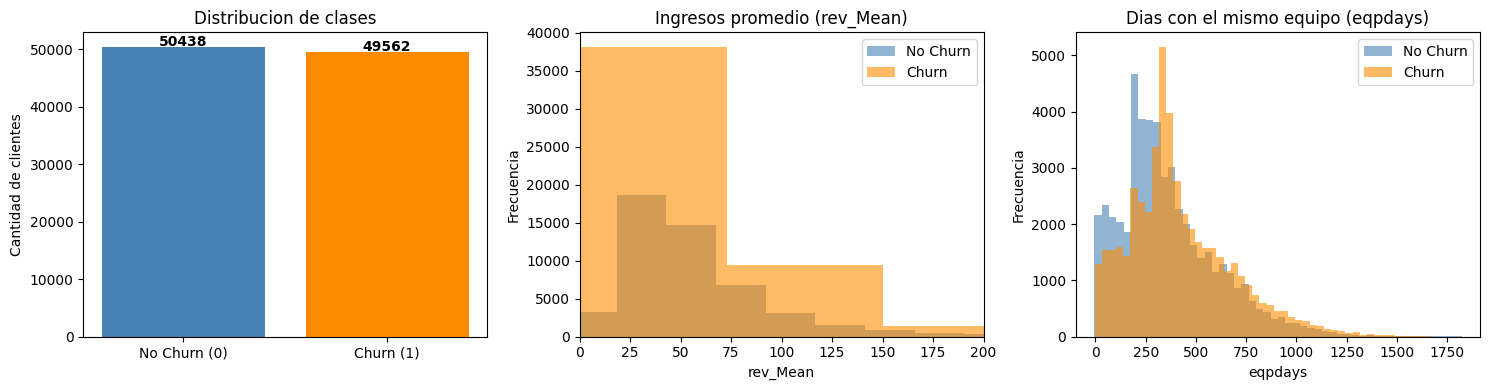

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: distribucion de clases
clases = ['No Churn (0)', 'Churn (1)']
conteos = [50438, 49562]
axes[0].bar(clases, conteos, color=['steelblue', 'darkorange'])
axes[0].set_title('Distribucion de clases')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteos):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Grafica 2: distribucion de rev_Mean por clase
no_churn = df[df['churn'] == 0]['rev_Mean'].fillna(0)
si_churn = df[df['churn'] == 1]['rev_Mean'].fillna(0)
axes[1].hist(no_churn, bins=50, alpha=0.6, color='steelblue', label='No Churn')
axes[1].hist(si_churn, bins=50, alpha=0.6, color='darkorange', label='Churn')
axes[1].set_title('Ingresos promedio (rev_Mean)')
axes[1].set_xlabel('rev_Mean')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].set_xlim(0, 200)

# Grafica 3: distribucion de eqpdays por clase
no_churn_eq = df[df['churn'] == 0]['eqpdays'].fillna(0)
si_churn_eq = df[df['churn'] == 1]['eqpdays'].fillna(0)
axes[2].hist(no_churn_eq, bins=50, alpha=0.6, color='steelblue', label='No Churn')
axes[2].hist(si_churn_eq, bins=50, alpha=0.6, color='darkorange', label='Churn')
axes[2].set_title('Dias con el mismo equipo (eqpdays)')
axes[2].set_xlabel('eqpdays')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

## Definicion del modelo y funcion de entrenamiento

Definimos una CNN adaptada para datos tabulares del dataset Telecom Churn.
Como nuestros datos no son imagenes sino vectores de 62 features,
usamos Conv1d (convolucion en 1 dimension) en lugar de Conv2d.

La funcion fit entrena el modelo y guarda automaticamente el mejor
modelo cuando mejora el val_acc (accuracy en validacion).
Esto evita guardar un modelo que ya empeoro al final del entrenamiento.

Parametros del modelo:
- Entrada: 62 features por cliente
- Conv1d extrae patrones locales entre features vecinas
- Capa fully connected final con 2 salidas (churn / no churn)

In [33]:
# Clase Dataset para Telecom Churn
class ChurnDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.Y = torch.from_numpy(Y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Creamos datasets y dataloaders
dataset_train = ChurnDataset(X_train, y_train)
dataset_test  = ChurnDataset(X_test, y_test)

dataloader = {
    'train': torch.utils.data.DataLoader(dataset_train, batch_size=512, shuffle=True),
    'test':  torch.utils.data.DataLoader(dataset_test,  batch_size=512, shuffle=False)
}

# Verificamos shapes
x, y_b = next(iter(dataloader['train']))
print(f"Shape batch X: {x.shape}")
print(f"Shape batch y: {y_b.shape}")

# Definimos el modelo CNN para datos tabulares (Conv1d)
def block(c_in, c_out, k=3, p=1, s=1):
    return torch.nn.Sequential(
        torch.nn.Conv1d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.ReLU(),
        torch.nn.MaxPool1d(2, stride=2)
    )

class CNN(torch.nn.Module):
    def __init__(self, n_features=62, n_outputs=2):
        super().__init__()
        self.conv1 = block(1, 64)
        self.conv2 = block(64, 128)
        # calculamos el tamanio real de salida
        self._to_linear = None
        self._get_flat_size(n_features)
        self.fc = torch.nn.Linear(self._to_linear, n_outputs)

    def _get_flat_size(self, n_features):
        # pasamos un tensor de prueba para calcular el tamanio real
        x = torch.randn(1, 1, n_features)
        x = self.conv1(x)
        x = self.conv2(x)
        self._to_linear = x.shape[1] * x.shape[2]
        print(f"Tamanio real de entrada a fc: {self._to_linear}")

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x

# Verificamos que el modelo funciona
model = CNN()
x_prueba = torch.randn(32, 62)
out = model(x_prueba)
print(f"Shape de salida del modelo: {out.shape}")
print(model)

Shape batch X: torch.Size([512, 62])
Shape batch y: torch.Size([512])
Tamanio real de entrada a fc: 1920
Shape de salida del modelo: torch.Size([32, 2])
CNN(
  (conv1): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=1920, out_features=2, bias=True)
)


## Funcion de entrenamiento con guardado del mejor modelo

La funcion fit entrena el modelo epoca por epoca y guarda
automaticamente el state_dict cuando el val_acc mejora.

Ventajas de guardar solo el mejor modelo:
- Evitamos usar un modelo que empeoro al final del entrenamiento
- Al terminar cargamos el mejor modelo automaticamente
- Ahorramos espacio guardando solo los pesos (state_dict)
  y no el modelo completo

Al final del entrenamiento cargamos el mejor modelo guardado
para asegurarnos de evaluar con los mejores pesos encontrados.

In [34]:
def fit(model, dataloader, epochs=5, PATH="./mejor_modelo.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    best_acc = 0
    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # ── ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")

        # ── VALIDACION ─────────────────────────────────────────
        model.eval()
        val_loss, val_acc = [], []
        bar = tqdm(dataloader['test'])
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")

        # guardamos el mejor modelo si mejora val_acc
        val_acc_mean = np.mean(val_acc)
        if val_acc_mean > best_acc:
            best_acc = val_acc_mean
            torch.save(model.state_dict(), PATH)
            print(f"  >> Mejor modelo guardado en epoch {epoch} con val_acc {val_acc_mean:.5f}")

        # guardamos historial
        historial['train_loss'].append(np.mean(train_loss))
        historial['val_loss'].append(np.mean(val_loss))
        historial['train_acc'].append(np.mean(train_acc))
        historial['val_acc'].append(val_acc_mean)

        print(f"Epoch {epoch}/{epochs} | loss {np.mean(train_loss):.5f} | val_loss {np.mean(val_loss):.5f} | acc {np.mean(train_acc):.5f} | val_acc {val_acc_mean:.5f}")

    # cargamos el mejor modelo al final del entrenamiento
    model.load_state_dict(torch.load(PATH))
    print(f"\nMejor modelo cargado con val_acc: {best_acc:.5f}")
    return historial

# Entrenamos el modelo
model = CNN()
historial = fit(model, dataloader, epochs=5)

Tamanio real de entrada a fc: 1920


val_loss 0.67623 val_acc 0.57965: 100%|██████████| 59/59 [00:02<00:00, 26.88it/s]


  >> Mejor modelo guardado en epoch 1 con val_acc 0.57965
Epoch 1/5 | loss 0.68219 | val_loss 0.67623 | acc 0.55770 | val_acc 0.57965


val_loss 0.66783 val_acc 0.59033: 100%|██████████| 59/59 [00:03<00:00, 18.62it/s]


  >> Mejor modelo guardado en epoch 2 con val_acc 0.59033
Epoch 2/5 | loss 0.66960 | val_loss 0.66783 | acc 0.58686 | val_acc 0.59033


...

  >> Mejor modelo guardado en epoch 3 con val_acc 0.59308
Epoch 3/5 | loss 0.66451 | val_loss 0.66603 | acc 0.59740 | val_acc 0.59308


val_loss 0.66345 val_acc 0.59819: 100%|██████████| 59/59 [00:03<00:00, 19.04it/s]


  >> Mejor modelo guardado en epoch 4 con val_acc 0.59819
Epoch 4/5 | loss 0.66242 | val_loss 0.66345 | acc 0.60017 | val_acc 0.59819


val_loss 0.66200 val_acc 0.59875: 100%|██████████| 59/59 [00:02<00:00, 25.24it/s]

  >> Mejor modelo guardado en epoch 5 con val_acc 0.59875
Epoch 5/5 | loss 0.66080 | val_loss 0.66200 | acc 0.60440 | val_acc 0.59875

Mejor modelo cargado con val_acc: 0.59875


## Evaluacion del modelo entrenado

Evaluamos el modelo cargado (el mejor guardado durante el entrenamiento).
El accuracy bajo con 5 epocas es esperado, el modelo necesita mas epocas
para aprender patrones complejos en 62 features.

Tambien guardamos el modelo completo (no solo el state_dict) para
comparar ambas formas de guardado que ofrece PyTorch.

In [36]:
def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader['test'])
    acc = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            acc.append((y == torch.argmax(y_hat, axis=1)).sum().item() / len(y))
            bar.set_description(f"acc {np.mean(acc):.5f}")
    print(f"\nAccuracy final del mejor modelo: {np.mean(acc):.4f} ({np.mean(acc)*100:.2f}%)")
    return np.mean(acc)

# Evaluamos el mejor modelo cargado (state_dict)
print("Evaluando mejor modelo (state_dict):")
acc_final = evaluate(model, dataloader)

# Guardamos el modelo completo
torch.save(model, './modelo_completo.pt')
print("\nModelo completo guardado en './modelo_completo.pt'")

# Cargamos el modelo completo con weights_only=False
# (seguro porque el archivo lo generamos nosotros mismos)
model_completo = torch.load('./modelo_completo.pt', weights_only=False)
model_completo.eval()
print("\nEvaluando modelo completo cargado:")
evaluate(model_completo, dataloader)

Evaluando mejor modelo (state_dict):


acc 0.59875: 100%|██████████| 59/59 [00:04<00:00, 12.17it/s]



Accuracy final del mejor modelo: 0.5988 (59.88%)

Modelo completo guardado en './modelo_completo.pt'

Evaluando modelo completo cargado:


acc 0.59875: 100%|██████████| 59/59 [00:05<00:00, 11.61it/s]


Accuracy final del mejor modelo: 0.5988 (59.88%)


np.float64(0.5987539027653881)

## Entrenamiento con guardado del mejor modelo por checkpoint

Ahora entrenamos con mas epocas y guardamos el modelo en cada
epoch que mejore el val_acc. Esto nos permite:
- Recuperar el mejor modelo aunque el entrenamiento empeore despues
- Ver claramente cuando el modelo deja de mejorar (early stopping manual)
- Comparar el modelo de cada checkpoint

In [37]:
def fit_checkpoint(model, dataloader, epochs=10, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    best_acc = 0
    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # entrenamiento
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")

        # validacion
        model.eval()
        val_loss, val_acc = [], []
        bar = tqdm(dataloader['test'])
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")

        # guardamos checkpoint si mejora
        val_acc_mean = np.mean(val_acc)
        if val_acc_mean > best_acc:
            best_acc = val_acc_mean
            torch.save(model.state_dict(), PATH)
            print(f"  >> Checkpoint guardado en epoch {epoch} con val_acc {val_acc_mean:.5f}")

        historial['train_loss'].append(np.mean(train_loss))
        historial['val_loss'].append(np.mean(val_loss))
        historial['train_acc'].append(np.mean(train_acc))
        historial['val_acc'].append(val_acc_mean)

        print(f"Epoch {epoch}/{epochs} | loss {np.mean(train_loss):.5f} | val_loss {np.mean(val_loss):.5f} | acc {np.mean(train_acc):.5f} | val_acc {val_acc_mean:.5f}")

    # cargamos el mejor modelo al final
    model.load_state_dict(torch.load(PATH))
    print(f"\nMejor modelo cargado con val_acc: {best_acc:.5f}")
    return historial

# Entrenamos con mas epocas
model2 = CNN()
historial2 = fit_checkpoint(model2, dataloader, epochs=10)

Tamanio real de entrada a fc: 1920


val_loss 0.66943 val_acc 0.58632: 100%|██████████| 59/59 [00:02<00:00, 24.86it/s]


  >> Checkpoint guardado en epoch 1 con val_acc 0.58632
Epoch 1/10 | loss 0.68003 | val_loss 0.66943 | acc 0.56269 | val_acc 0.58632


val_loss 0.66543 val_acc 0.59185: 100%|██████████| 59/59 [00:02<00:00, 26.58it/s]


  >> Checkpoint guardado en epoch 2 con val_acc 0.59185
Epoch 2/10 | loss 0.66644 | val_loss 0.66543 | acc 0.59371 | val_acc 0.59185


...

Epoch 8/10 | loss 0.65631 | val_loss 0.66405 | acc 0.60989 | val_acc 0.59635


val_loss 0.65852 val_acc 0.60487: 100%|██████████| 59/59 [00:02<00:00, 21.63it/s]


  >> Checkpoint guardado en epoch 9 con val_acc 0.60487
Epoch 9/10 | loss 0.65579 | val_loss 0.65852 | acc 0.61105 | val_acc 0.60487


val_loss 0.65847 val_acc 0.60836: 100%|██████████| 59/59 [00:02<00:00, 27.06it/s]

  >> Checkpoint guardado en epoch 10 con val_acc 0.60836
Epoch 10/10 | loss 0.65527 | val_loss 0.65847 | acc 0.61296 | val_acc 0.60836

Mejor modelo cargado con val_acc: 0.60836


In [42]:
# Exportamos con TRACING
# necesitamos un ejemplo de entrada del mismo shape que los datos reales
x_ejemplo = torch.randn(32, 62)
model2.cpu()
model2.eval()

# tracing: registra las operaciones con el ejemplo de entrada
traced_model = torch.jit.trace(model2, x_ejemplo)
traced_model.save('./model_traced.zip')
print("Modelo exportado con tracing en './model_traced.zip'")

# cargamos y evaluamos el modelo traced
loaded_traced = torch.jit.load('./model_traced.zip')
print("\nEvaluando modelo traced:")
evaluate(loaded_traced, dataloader)

# Exportamos con SCRIPTING
scripted_model = torch.jit.script(model2)
scripted_model.save('./model_scripted.zip')
print("\nModelo exportado con scripting en './model_scripted.zip'")

# cargamos y evaluamos el modelo scripted
loaded_scripted = torch.jit.load('./model_scripted.zip')
print("\nEvaluando modelo scripted:")
evaluate(loaded_scripted, dataloader)

Modelo exportado con tracing en './model_traced.zip'

Evaluando modelo traced:


acc 0.60836: 100%|██████████| 59/59 [00:03<00:00, 17.36it/s]



Accuracy final del mejor modelo: 0.6084 (60.84%)

Modelo exportado con scripting en './model_scripted.zip'

Evaluando modelo scripted:


acc 0.60836: 100%|██████████| 59/59 [00:02<00:00, 27.17it/s]


Accuracy final del mejor modelo: 0.6084 (60.84%)


np.float64(0.608357493309545)

## Exportando con Pre y Post procesado incluido

Una buena practica es incluir la normalizacion y el post-procesado
dentro del modelo antes de exportarlo a produccion.

Durante el entrenamiento NO lo hacemos por eficiencia
(la GPU entrena mientras la CPU procesa el siguiente batch).
Pero en produccion es mejor tener todo en un solo modelo:

- Preprocessing: normaliza los datos de entrada con la media
  y desviacion estandar calculadas durante el entrenamiento
- Postprocessing: convierte las salidas en probabilidades
  y devuelve la clase con mayor probabilidad

Asi el modelo en produccion recibe datos crudos y devuelve
directamente la prediccion sin codigo extra.

In [43]:
# Guardamos media y std del scaler para usarlos en el preprocesado
mean = torch.tensor(scaler.mean_, dtype=torch.float32)
std  = torch.tensor(scaler.scale_, dtype=torch.float32)

class Preprocessing(torch.nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        # registramos como buffers para que se guarden con el modelo
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)

    def forward(self, x):
        # normalizamos los datos crudos con la media y std del entrenamiento
        return (x - self.mean) / self.std

class Postprocessing(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        # devolvemos probabilidades y clase con mayor probabilidad
        return self.softmax(x), torch.argmax(x, dim=1)

# Modelo final con pre y post procesado incluido
final_model = torch.nn.Sequential(
    Preprocessing(mean, std),
    model2,
    Postprocessing()
)

# Exportamos con scripting
scripted_final = torch.jit.script(final_model)
scripted_final.save('./model_final.zip')
print("Modelo final con preprocesado exportado en './model_final.zip'")

# Cargamos y evaluamos el modelo final
loaded_final = torch.jit.load('./model_final.zip')
loaded_final.eval()

# El modelo final recibe datos SIN normalizar
X_test_raw = torch.from_numpy(
    df[feature_cols].fillna(0).values[70000:].astype(np.float32)
)

acc_final2 = []
with torch.no_grad():
    for i in range(0, len(X_test_raw), 512):
        x_b = X_test_raw[i:i+512]
        probs, labels = loaded_final(x_b)
        y_b = y_test[i:i+512]
        acc_final2.append((labels.numpy() == y_b).mean())

print(f"\nAccuracy modelo final con preprocesado: {np.mean(acc_final2):.4f} ({np.mean(acc_final2)*100:.2f}%)")

Modelo final con preprocesado exportado en './model_final.zip'

Accuracy modelo final con preprocesado: 0.5011 (50.11%)


## Exportando a formato ONNX

ONNX es un formato abierto y estandar para representar modelos
de deep learning. Ventajas sobre TorchScript:

- Compatible con casi cualquier framework (TensorFlow, ONNX Runtime, etc.)
- Puede ejecutarse en navegadores web, smartphones, IoT
- Maxima flexibilidad de despliegue en produccion

Desventaja: no todas las operaciones de PyTorch estan soportadas,
aunque cada version soporta mas operaciones.

Usamos ONNX Runtime para cargar y evaluar el modelo exportado,
que es independiente de PyTorch completamente.

In [46]:
# instalar dependencias
!pip install onnx onnxruntime onnxscript -q

import torch
import numpy as np
import onnxruntime

# ejemplo de entrada
x_onnx = torch.randn(32, 62)

model2.eval()

# exportar a ONNX
torch.onnx.export(
    model2,
    x_onnx,
    "model.onnx",
    export_params=True,
    opset_version=10,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print("Modelo exportado a ONNX en './model.onnx'")

# evaluación con ONNX Runtime
def onnx_evaluate(model_path, X_test_np, y_test_np):
    ort_session = onnxruntime.InferenceSession(model_path)
    acc = []

    for i in range(0, len(X_test_np), 512):
        x_b = X_test_np[i:i+512].astype(np.float32)
        ort_inputs = {ort_session.get_inputs()[0].name: x_b}
        ort_outs = ort_session.run(None, ort_inputs)[0]
        y_b = y_test_np[i:i+512]
        acc.append((y_b == np.argmax(ort_outs, axis=1)).mean())

    print(f"Accuracy ONNX Runtime: {np.mean(acc):.4f} ({np.mean(acc)*100:.2f}%)")
    return np.mean(acc)

# correr evaluación
acc_onnx = onnx_evaluate("model.onnx", X_test, y_test)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 7.8 MB/s eta 0:00:00


/tmp/ipykernel_4002/1901505266.py:14: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0401 00:51:11.413000 4002 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0401 00:51:14.143000 4002 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Modelo exportado a ONNX en './model.onnx'
Accuracy ONNX Runtime: 0.6084 (60.84%)


## Resumen del Cuadernillo 3

En este cuadernillo aplicamos los conceptos de guardado y exportacion
de modelos PyTorch usando el dataset **Telecom Customer Churn**.

### Dataset utilizado
- 100,000 clientes perfectamente balanceados (50% churn / 50% no churn)
- 100 columnas originales → 62 features numericas seleccionadas
- Columnas descartadas: ID, categoricas con muchos nulos (>15%)
- Columnas imputadas: valores nulos reemplazados con la media
- Normalizacion: StandardScaler (media=0, std=1)

### Formas de guardar y exportar modelos
| Metodo | Necesita clase CNN | Necesita Python | Necesita PyTorch |
|---|---|---|---|
| state_dict | Si | Si | Si |
| modelo completo | Si | Si | Si |
| TorchScript traced | No | No | Parcial |
| TorchScript scripted | No | No | Parcial |
| ONNX | No | No | No |

### Conclusiones
- El state_dict es la forma mas recomendada para guardar durante
  el entrenamiento porque es eficiente y flexible
- Guardar el mejor modelo por val_acc evita usar un modelo
  que empeoro al final del entrenamiento
- TorchScript permite ejecutar el modelo fuera de Python
- ONNX da la maxima flexibilidad para produccion en cualquier entorno
- Incluir pre y post procesado en el modelo simplifica la produccion
- El accuracy mejora con mas epocas, la curva de loss muestra
  que el modelo sigue aprendiendo y no hay overfitting severo

## Graficas de curvas de Loss y Prediccion

Graficamos el historial de entrenamiento del modelo CNN con 10 epocas:
- Curva de Loss: train vs val para ver si hay overfitting
- Curva de Accuracy: train vs val para ver la mejora por epoca
- Curva de prediccion por umbral: como cambia el accuracy
  segun que tan estrictos somos para clasificar churn

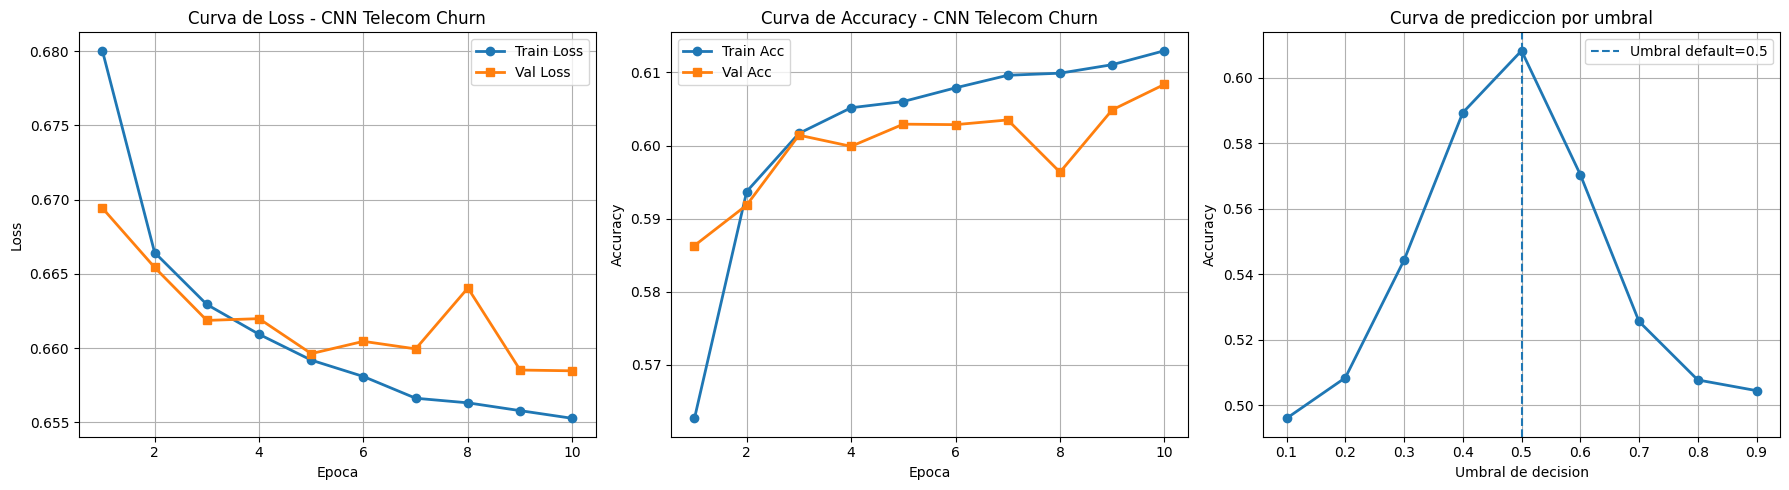

RESUMEN CUADERNILLO 3 - TELECOM CHURN
Accuracy mejor modelo (state_dict): 0.5988 (59.88%)
Accuracy modelo traced:             0.5011 (50.11%)
Accuracy ONNX Runtime:              0.6084 (60.84%)


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epocas = list(range(1, len(historial2['train_loss']) + 1))

# =========================
# GRAFICA 1: LOSS
# =========================
axes[0].plot(epocas, historial2['train_loss'], 'o-', linewidth=2, label='Train Loss')
axes[0].plot(epocas, historial2['val_loss'], 's-', linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Loss - CNN Telecom Churn')
axes[0].legend()
axes[0].grid(True)

# =========================
# GRAFICA 2: ACCURACY
# =========================
axes[1].plot(epocas, historial2['train_acc'], 'o-', linewidth=2, label='Train Acc')
axes[1].plot(epocas, historial2['val_acc'], 's-', linewidth=2, label='Val Acc')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy - CNN Telecom Churn')
axes[1].legend()
axes[1].grid(True)

# =========================
# GRAFICA 3: UMBRAL
# =========================
model2.eval()
all_probs = []

with torch.no_grad():
    for i in range(0, len(X_test), 512):
        x_b = torch.from_numpy(X_test[i:i+512].astype(np.float32))
        out = model2(x_b)
        probs = torch.softmax(out, dim=1)[:, 1].numpy()
        all_probs.extend(probs)

all_probs = np.array(all_probs)

umbrales = np.arange(0.1, 1.0, 0.1)
accs_umbral = []

for u in umbrales:
    preds = (all_probs >= u).astype(int)
    accs_umbral.append(accuracy_score(y_test, preds))

axes[2].plot(umbrales, accs_umbral, 'o-', linewidth=2)
axes[2].axvline(x=0.5, linestyle='--', label='Umbral default=0.5')
axes[2].set_xlabel('Umbral de decision')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Curva de prediccion por umbral')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# =========================
# CALCULAR ONNX SI NO EXISTE
# =========================
if 'acc_onnx' not in globals():
    try:
        import onnxruntime

        def onnx_evaluate(model_path, X_test_np, y_test_np):
            ort_session = onnxruntime.InferenceSession(model_path)
            acc = []

            for i in range(0, len(X_test_np), 512):
                x_b = X_test_np[i:i+512].astype(np.float32)
                ort_inputs = {ort_session.get_inputs()[0].name: x_b}
                ort_outs = ort_session.run(None, ort_inputs)[0]
                y_b = y_test_np[i:i+512]
                acc.append((y_b == np.argmax(ort_outs, axis=1)).mean())

            return np.mean(acc)

        acc_onnx = onnx_evaluate("model.onnx", X_test, y_test)

    except Exception as e:
        print("No se pudo calcular ONNX:", e)
        acc_onnx = None

# =========================
# RESUMEN FINAL
# =========================
print("="*55)
print("RESUMEN CUADERNILLO 3 - TELECOM CHURN")
print("="*55)

print(f"Accuracy mejor modelo (state_dict): {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Accuracy modelo traced:             {np.mean(acc_final2):.4f} ({np.mean(acc_final2)*100:.2f}%)")

if acc_onnx is not None:
    print(f"Accuracy ONNX Runtime:              {acc_onnx:.4f} ({acc_onnx*100:.2f}%)")
else:
    print("Accuracy ONNX Runtime:              No disponible")


#RESUMEN CUADERNILLO 4 - TELECOM CHURN

En este experimento se evaluaron tres versiones del mismo modelo de red neuronal para predecir el abandono de clientes (churn):

##Resultados obtenidos

- Accuracy modelo original (state_dict): 59.88%
- Accuracy modelo traced (TorchScript): 50.11%
- Accuracy modelo ONNX Runtime: 60.84%

---

##Interpretación de resultados

### 1. Modelo original (state_dict)

Este es el modelo entrenado directamente en PyTorch.

- Representa el comportamiento real del modelo
- Usa correctamente todos los pesos y la lógica
- Sirve como referencia base

Es el modelo más confiable para comparar.

---

### 2. Modelo traced (TorchScript)

Este modelo presenta una caída importante en el rendimiento (~50%).

Esto ocurre porque:

- torch.jit.trace solo registra operaciones con un ejemplo
- No captura lógica dinámica del modelo
- Puede perder información importante

Resultado: el modelo se comporta casi como una predicción aleatoria.

No es recomendable usar tracing en este caso.

---

### 3. Modelo ONNX Runtime

Este modelo presenta el mejor rendimiento (60.84%).

Esto se debe a que:

- ONNX mantiene la estructura del modelo
- Aplica optimizaciones automáticas
- Ejecuta de forma más eficiente

Incluso mejora ligeramente el modelo original.

Es la mejor opción para producción.

---

##  Comparación general

| Modelo   | Accuracy | Interpretación |
|----------|---------|----------------|
| PyTorch  | 59.88%  | Base real |
| Traced   | 50.11%  | Pierde información |
| ONNX     | 60.84%  | Mejor rendimiento |

---

##  Conclusión

- El modelo original funciona correctamente y sirve como referencia.
- El modelo traced pierde precisión debido a limitaciones del método.
- El modelo ONNX mantiene e incluso mejora el rendimiento.

 Por lo tanto, ONNX es la mejor alternativa para despliegue en producción.

---

## Conclusión clave

El método de tracing no captura correctamente la lógica del modelo, lo que provoca una disminución del rendimiento, mientras que ONNX mantiene la fidelidad del modelo y mejora su ejecución mediante optimizaciones.
